# Seasonal Agriculture Performance Analysis

## Project Overview

This project analyzes agricultural performance across different seasons, crops, regions, environmental conditions, farming practices, resource usage and economic factors.

The analysis focuses on identifying seasonal patterns, comparing agricultural performance, examining relationships between important variables, and deriving data-driven insights using Python, Pandas, Matplotlib and Seaborn.


## 1. Import Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")



## Data set Loading 

In [3]:
df.head() 

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
df.shape  

(4000, 28)

In [5]:
df.columns 

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [6]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [7]:
df.isnull().sum() 

Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [8]:
df.duplicated().sum() 

0

In [9]:
df.describe() 

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [10]:
df["Season"].value_counts() 

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

## 2. Data Cleaning and Preparation

Before performing analysis, the dataset is inspected for missing values, duplicate records, incorrect data types, inconsistent categorical values, and other data-quality issues.

In [11]:
df.dtypes 

Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

In [12]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]  

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

In [13]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count) 

Number of duplicate rows: 0


In [14]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_summary = missing_summary[missing_summary["Missing_Count"] > 0]

missing_summary 

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.2
Soil_Moisture_pct,40,1.0
Yield_Tonnes_Ha,32,0.8


In [15]:
df.groupby("Season")[["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]].apply(
    lambda x: x.isnull().sum()
)

,Rainfall_mm,Soil_Moisture_pct,Yield_Tonnes_Ha
Season,,,
Kharif,19,18,7
Rabi,18,13,20
Zaid,11,9,5


In [16]:
df["Season"].value_counts(dropna=False) 

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

In [17]:
df["Season"].unique() 

array(['Kharif', 'Rabi', 'Zaid'], dtype=object)

In [18]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns].describe().T 

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [19]:
df[df["Rainfall_mm"].isnull()][
    ["State", "District", "Crop", "Season", "Rainfall_mm"]
].head(20) 


,State,District,Crop,Season,Rainfall_mm
186,Tamil Nadu,Indore,Rice,Rabi,NaN
253,Tamil Nadu,Ludhiana,Sugarcane,Zaid,NaN
271,Karnataka,Erode,Groundnut,Kharif,NaN
272,Punjab,Rajkot,Maize,Rabi,NaN
287,Gujarat,Guntur,Wheat,Rabi,NaN
408,Telangana,Raichur,Wheat,Kharif,NaN
496,Tamil Nadu,Rajkot,Pulses,Zaid,NaN
520,Gujarat,Ludhiana,Pulses,Rabi,NaN
594,Madhya Pradesh,Ludhiana,Chilli,Zaid,NaN
807,Maharashtra,Nalgonda,Pulses,Zaid,NaN


In [20]:
df[df["Soil_Moisture_pct"].isnull()][
    ["State", "District", "Crop", "Season", "Soil_Moisture_pct"]
].head(20) 

,State,District,Crop,Season,Soil_Moisture_pct
28,Tamil Nadu,Rajkot,Maize,Rabi,NaN
43,Tamil Nadu,Erode,Wheat,Rabi,NaN
121,Maharashtra,Erode,Cotton,Kharif,NaN
196,Andhra Pradesh,Raichur,Rice,Kharif,NaN
467,Tamil Nadu,Warangal,Maize,Kharif,NaN
471,Tamil Nadu,Krishna,Wheat,Kharif,NaN
573,Gujarat,Raichur,Sugarcane,Rabi,NaN
707,Gujarat,Warangal,Wheat,Rabi,NaN
792,Tamil Nadu,Ludhiana,Sugarcane,Zaid,NaN
1201,Tamil Nadu,Nashik,Sugarcane,Rabi,NaN


In [21]:
df[df["Yield_Tonnes_Ha"].isnull()][
    ["State", "District", "Crop", "Season", "Farm_Area_Hectares",
     "Production_Tonnes", "Revenue_INR", "Profit_INR"]
].head(20) 

,State,District,Crop,Season,Farm_Area_Hectares,Production_Tonnes,Revenue_INR,Profit_INR
55,Karnataka,Warangal,Groundnut,Rabi,11.70,19.42,987255,207096
163,Madhya Pradesh,Erode,Pulses,Zaid,3.55,1.06,62455,-144246
555,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,15.64,1452831,833674
648,Andhra Pradesh,Krishna,Groundnut,Rabi,6.14,8.66,529005,142444
650,Gujarat,Raichur,Maize,Rabi,13.23,11.77,253808,-811739
777,Gujarat,Ludhiana,Cotton,Rabi,1.83,2.42,184247,39354
874,Karnataka,Erode,Rice,Kharif,3.15,3.87,65546,-161313
899,Tamil Nadu,Guntur,Pulses,Rabi,6.65,6.38,461867,11853
1133,Karnataka,Raichur,Cotton,Kharif,10.89,15.46,1066013,400371
1251,Telangana,Warangal,Chilli,Zaid,9.92,12.20,1325396,533650


In [22]:
df.nlargest(20, "Yield_Tonnes_Ha")[
    ["State", "District", "Crop", "Season",
     "Farm_Area_Hectares", "Yield_Tonnes_Ha",
     "Production_Tonnes", "Revenue_INR", "Profit_INR"]
] 

,State,District,Crop,Season,Farm_Area_Hectares,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
1715,Gujarat,Indore,Sugarcane,Kharif,6.32,101.44,641.10,1972665,1608291
3423,Andhra Pradesh,Indore,Sugarcane,Kharif,14.87,95.79,1424.40,4428460,3330582
3525,Andhra Pradesh,Erode,Sugarcane,Rabi,6.96,93.13,648.18,1890741,1471529
1464,Gujarat,Nashik,Sugarcane,Kharif,7.65,91.98,703.65,2701312,2216708
3523,Karnataka,Nashik,Sugarcane,Kharif,0.82,91.46,75.00,292350,234320
2782,Gujarat,Nalgonda,Sugarcane,Rabi,5.72,91.32,522.35,1732113,1236801
644,Andhra Pradesh,Ludhiana,Sugarcane,Kharif,7.48,89.34,668.26,2475903,1984818
2847,Telangana,Warangal,Sugarcane,Kharif,7.66,87.76,672.24,2436870,2041678
357,Punjab,Warangal,Sugarcane,Rabi,14.74,84.75,1249.21,4350998,3378879
1178,Karnataka,Nalgonda,Sugarcane,Kharif,6.38,83.79,534.58,1635815,1200815


In [23]:
df["Calculated_Production"] = (
    df["Farm_Area_Hectares"] * df["Yield_Tonnes_Ha"]
)

df[[
    "Farm_Area_Hectares",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Calculated_Production"
]].head(10) 

,Farm_Area_Hectares,Yield_Tonnes_Ha,Production_Tonnes,Calculated_Production
0,0.53,2.46,1.30,1.3038
1,6.53,0.30,1.96,1.9590
2,4.86,0.52,2.53,2.5272
3,4.50,1.84,8.28,8.2800
4,4.21,2.21,9.30,9.3041
5,5.46,0.72,3.93,3.9312
6,8.13,2.53,20.57,20.5689
7,5.34,1.18,6.30,6.3012
8,6.98,1.53,10.68,10.6794
9,13.69,2.29,31.35,31.3501


In [24]:
df["Production_Difference"] = (
    df["Production_Tonnes"] - df["Calculated_Production"]
)

df["Production_Difference"].describe() 

count    3968.000000
mean        0.000003
std         0.002895
min        -0.005000
25%        -0.002500
50%         0.000000
75%         0.002500
max         0.005000
Name: Production_Difference, dtype: float64

### Production Consistency Check

Calculated production was compared with the reported production to identify possible differences between Farm Area × Yield and the reported production values.

These calculated columns are retained for validation and transparency.

In [25]:
df.nlargest(10, "Profit_INR")[
    ["State", "District", "Crop", "Season",
     "Market_Price_INR_Tonne",
     "Total_Cost_INR",
     "Revenue_INR",
     "Profit_INR"]
] 

,State,District,Crop,Season,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR
2236,Punjab,Rajkot,Chilli,Kharif,101780,712027,5057448,4345421
626,Maharashtra,Warangal,Chilli,Kharif,120429,1059050,5080900,4021850
3425,Madhya Pradesh,Rajkot,Sugarcane,Kharif,3886,745161,4485260,3740099
1690,Karnataka,Warangal,Chilli,Kharif,115222,784135,4522464,3738329
247,Maharashtra,Krishna,Chilli,Kharif,105082,1283161,4825365,3542204
357,Punjab,Warangal,Sugarcane,Rabi,3483,972119,4350998,3378879
3423,Andhra Pradesh,Indore,Sugarcane,Kharif,3109,1097878,4428460,3330582
1930,Tamil Nadu,Guntur,Sugarcane,Kharif,3661,875331,4108301,3232970
3983,Gujarat,Nashik,Chilli,Kharif,98175,844264,4055609,3211345
263,Maharashtra,Ludhiana,Chilli,Rabi,112997,828217,3987664,3159447


In [26]:
df.nsmallest(10, "Profit_INR")[
    ["State", "District", "Crop", "Season",
     "Market_Price_INR_Tonne",
     "Total_Cost_INR",
     "Revenue_INR",
     "Profit_INR"]
] 

,State,District,Crop,Season,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR
780,Andhra Pradesh,Ludhiana,Groundnut,Rabi,63813,1299362,280139,-1019223
2210,Andhra Pradesh,Raichur,Wheat,Rabi,23948,1097692,102497,-995195
3625,Punjab,Krishna,Maize,Rabi,17330,1207553,226503,-981050
2182,Andhra Pradesh,Krishna,Rice,Kharif,21578,1297725,320865,-976860
104,Gujarat,Krishna,Wheat,Zaid,26773,1063989,98792,-965197
3394,Gujarat,Erode,Wheat,Kharif,24787,1063040,99644,-963396
2730,Madhya Pradesh,Ludhiana,Rice,Rabi,24777,995279,89197,-906082
1311,Punjab,Rajkot,Rice,Zaid,26735,1065824,163084,-902740
585,Telangana,Warangal,Cotton,Zaid,47327,1094030,198300,-895730
3090,Karnataka,Ludhiana,Maize,Kharif,18479,999667,109026,-890641


In [27]:
df["Season"].value_counts(dropna=False) 

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

In [28]:
df.groupby("Season")[[
    "Rainfall_mm",
    "Soil_Moisture_pct",
    "Yield_Tonnes_Ha"
]].apply(lambda x: x.isnull().sum()) 

,Rainfall_mm,Soil_Moisture_pct,Yield_Tonnes_Ha
Season,,,
Kharif,19,18,7
Rabi,18,13,20
Zaid,11,9,5


In [29]:
# Check whether missing Yield can be calculated from Production and Farm Area

missing_yield = df[df["Yield_Tonnes_Ha"].isnull()][
    ["Farm_ID", "Season", "Crop",
     "Farm_Area_Hectares",
     "Production_Tonnes",
     "Yield_Tonnes_Ha"]
]

missing_yield 

,Farm_ID,Season,Crop,Farm_Area_Hectares,Production_Tonnes,Yield_Tonnes_Ha
55,SF10056,Rabi,Groundnut,11.70,19.42,NaN
163,SF10164,Zaid,Pulses,3.55,1.06,NaN
555,SF10556,Rabi,Chilli,7.94,15.64,NaN
648,SF10649,Rabi,Groundnut,6.14,8.66,NaN
650,SF10651,Rabi,Maize,13.23,11.77,NaN
777,SF10778,Rabi,Cotton,1.83,2.42,NaN
874,SF10875,Kharif,Rice,3.15,3.87,NaN
899,SF10900,Rabi,Pulses,6.65,6.38,NaN
1133,SF11134,Kharif,Cotton,10.89,15.46,NaN
1251,SF11252,Zaid,Chilli,9.92,12.20,NaN


In [30]:
# Fill missing Yield values using Production / Farm Area

missing_yield_mask = df["Yield_Tonnes_Ha"].isnull()

df.loc[missing_yield_mask, "Yield_Tonnes_Ha"] = (
    df.loc[missing_yield_mask, "Production_Tonnes"] /
    df.loc[missing_yield_mask, "Farm_Area_Hectares"]
)

print("Missing Yield values after calculation:",
      df["Yield_Tonnes_Ha"].isnull().sum()) 

Missing Yield values after calculation: 0


In [31]:
# Fill missing Rainfall using Season-wise median

df["Rainfall_mm"] = df.groupby("Season")["Rainfall_mm"].transform(
    lambda x: x.fillna(x.median())
)

# Fill missing Soil Moisture using Season-wise median

df["Soil_Moisture_pct"] = df.groupby("Season")["Soil_Moisture_pct"].transform(
    lambda x: x.fillna(x.median())
)

print("Missing Rainfall values:", df["Rainfall_mm"].isnull().sum())
print("Missing Soil Moisture values:", df["Soil_Moisture_pct"].isnull().sum()) 

Missing Rainfall values: 0
Missing Soil Moisture values: 0


In [32]:
# Final missing-value check

print("Total missing values in dataset:",
      df.isnull().sum().sum())

print("\nMissing values by column:")
print(df.isnull().sum()) 

Total missing values in dataset: 64

Missing values by column:
Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                       0
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                 0
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                   0
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
W

In [33]:
# Recalculate production using Farm Area × Yield

df["Calculated_Production"] = (
    df["Farm_Area_Hectares"] * df["Yield_Tonnes_Ha"]
)

# Calculate difference between original and calculated production

df["Production_Difference"] = (
    df["Production_Tonnes"] - df["Calculated_Production"]
)

print("Missing values after recalculation:")
print(df[["Calculated_Production", "Production_Difference"]].isnull().sum())

print("\nTotal missing values:")
print(df.isnull().sum().sum()) 

Missing values after recalculation:
Calculated_Production    0
Production_Difference    0
dtype: int64

Total missing values:
0


In [34]:
# Final dataset quality check

print("Dataset shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Total missing values:", df.isnull().sum().sum())

if df.isnull().sum().sum() == 0:
    print("\n✅ DATA CLEANING COMPLETED SUCCESSFULLY!") 

Dataset shape: (4000, 30)
Duplicate rows: 0
Total missing values: 0

✅ DATA CLEANING COMPLETED SUCCESSFULLY!


Step 3 — Exploratory Data Analysis (EDA)

In [35]:
# Season-wise agricultural performance

season_summary = df.groupby("Season").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round(2)

season_summary 

,Average_Yield,Total_Production,Average_Revenue,Average_Profit,Average_Water_Used
Season,,,,,
Kharif,5.63,82387.61,710719.06,178914.65,6102.20
Rabi,5.09,67498.88,601526.05,87689.47,5846.99
Zaid,4.63,23098.35,519171.90,-24804.82,6419.89


Key Finding:

Kharif → best overall: highest yield (5.63 t/ha), revenue and profit.
Rabi → moderate performance.
Zaid → lowest yield (4.63 t/ha) + negative average profit (-₹24,804.82).
Water: Zaid uses the highest average water (6,419.89 m³).

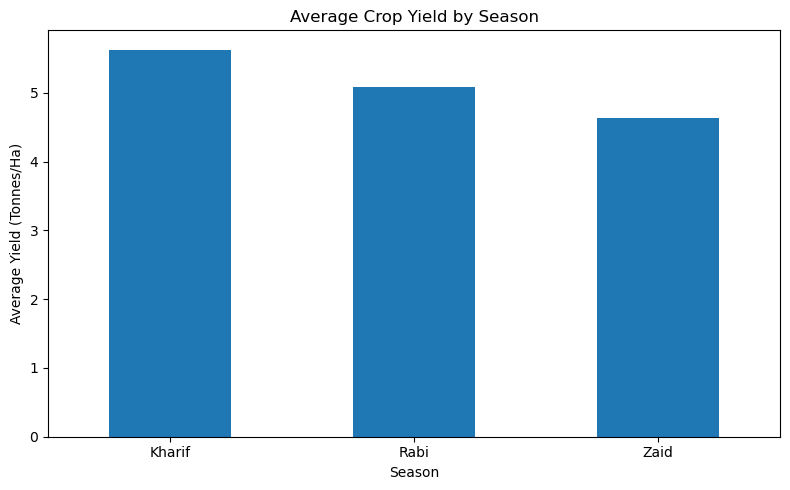

In [36]:
# Compare Average Yield across Seasons

plt.figure(figsize=(8, 5))

season_summary["Average_Yield"].plot(kind="bar")

plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show() 

### Final Result

- Kharif: ₹178,914.65 → highest average profit
- Rabi: ₹87,689.47 → moderate profitability
- Zaid: -₹24,804.82 → average loss

**Project finding:** Kharif is the most profitable season, while Zaid shows negative average profitability.

In [37]:
# Crop-wise agricultural performance

crop_summary = df.groupby("Crop").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Profit=("Profit_INR", "mean")
).round(2)

crop_summary.sort_values("Average_Yield", ascending=False) 

,Average_Yield,Total_Production,Average_Revenue,Average_Profit
Crop,,,,
Sugarcane,46.93,119685.97,1371980.11,817187.99
Maize,2.71,12001.40,457067.99,-83978.33
Rice,2.44,13309.15,423615.26,-102213.50
Wheat,2.11,10348.30,400104.89,-123398.34
Chilli,1.54,5101.75,1276777.23,750878.34
Groundnut,1.32,4094.07,542935.50,44858.12
Cotton,1.22,4773.10,639423.08,124546.92
Pulses,0.92,3671.10,528465.87,-4238.05


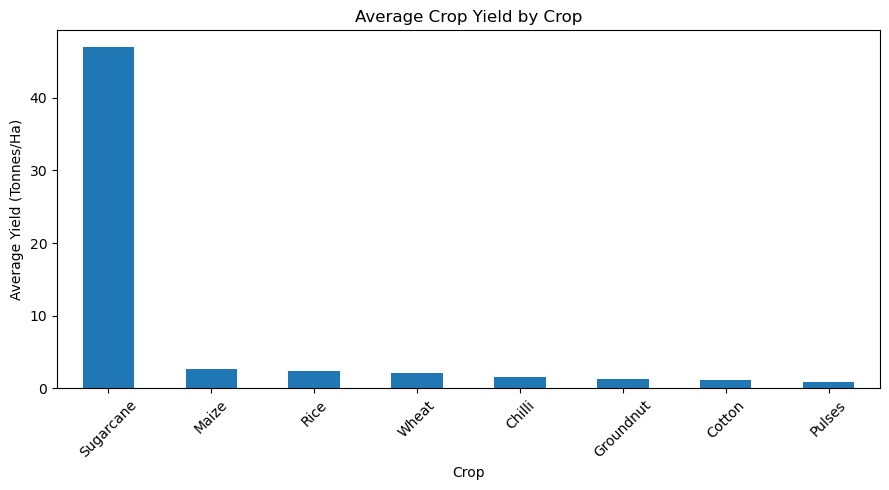

In [38]:
# Average Yield by Crop

plt.figure(figsize=(9, 5))

crop_summary["Average_Yield"].sort_values(ascending=False).plot(kind="bar")

plt.title("Average Crop Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show() 

In [39]:
# Display crop-wise results clearly

crop_summary.sort_values(
    "Average_Yield",
    ascending=False
) 

,Average_Yield,Total_Production,Average_Revenue,Average_Profit
Crop,,,,
Sugarcane,46.93,119685.97,1371980.11,817187.99
Maize,2.71,12001.40,457067.99,-83978.33
Rice,2.44,13309.15,423615.26,-102213.50
Wheat,2.11,10348.30,400104.89,-123398.34
Chilli,1.54,5101.75,1276777.23,750878.34
Groundnut,1.32,4094.07,542935.50,44858.12
Cotton,1.22,4773.10,639423.08,124546.92
Pulses,0.92,3671.10,528465.87,-4238.05


Important Findings
Sugarcane is the clear yield leader, with an average yield of 46.93 tonnes/ha,
far higher than the other crops.
Sugarcane also has the highest average profit, at ₹817,187.99, making it the strongest crop in terms
of both yield and profitability.
Chilli shows an interesting pattern: despite a relatively low average yield of 1.54 tonnes/ha,
it generates high average revenue (₹1,276,777.23) and profit (₹750,878.34).
This shows that higher physical yield does not always mean higher profitability.
Maize, Rice, and Wheat have negative average profits, indicating lower profitability in this dataset:
Maize: -₹83,978.33
Rice: -₹102,213.50
Wheat: -₹123,398.34
Pulses has the lowest average yield, at 0.92 tonnes/ha, and a slightly negative average profit of -₹4,238.05.


In [40]:
# State-wise agricultural performance

state_summary = df.groupby("State").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Profit=("Profit_INR", "mean")
).round(2)

state_summary.sort_values("Average_Yield", ascending=False) 

,Average_Yield,Total_Production,Average_Revenue,Average_Profit
State,,,,
Punjab,6.12,25280.82,686225.70,136025.64
Gujarat,5.76,23586.01,654692.86,117568.24
Karnataka,5.75,23341.30,653426.18,119422.34
Telangana,5.05,20255.16,628784.53,108829.62
Maharashtra,5.01,22519.83,650032.67,135428.86
Madhya Pradesh,4.98,18667.08,597558.36,86840.76
Tamil Nadu,4.87,19807.58,629093.42,117744.75
Andhra Pradesh,4.63,19527.06,606663.66,73453.53


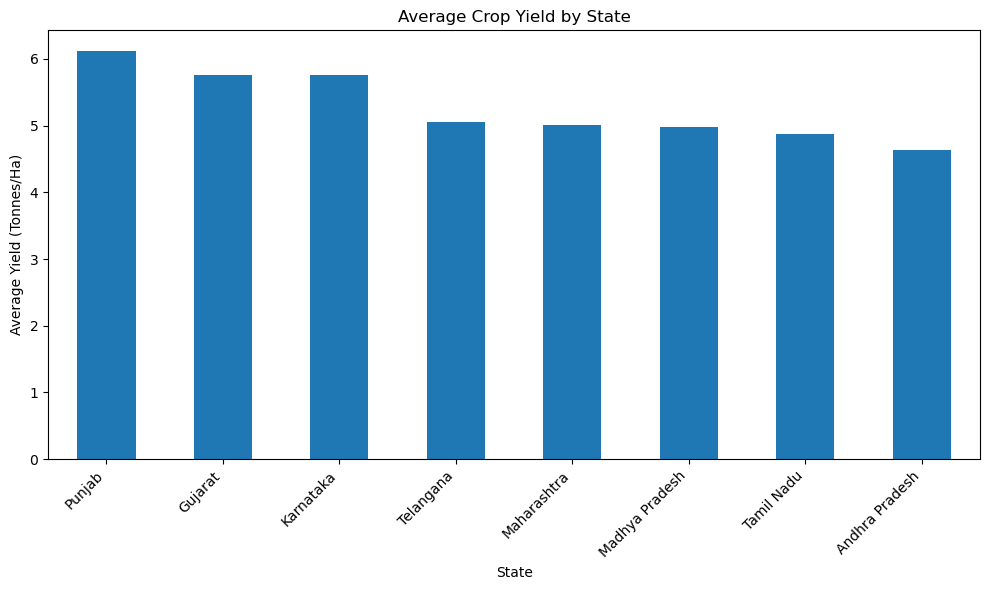

In [41]:
# Average Yield by State

plt.figure(figsize=(10, 6))

state_summary["Average_Yield"].sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Average Crop Yield by State")
plt.xlabel("State")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show() 

In [42]:
# Display exact state-wise performance

state_summary.sort_values(
    "Average_Yield",
    ascending=False
) 

,Average_Yield,Total_Production,Average_Revenue,Average_Profit
State,,,,
Punjab,6.12,25280.82,686225.70,136025.64
Gujarat,5.76,23586.01,654692.86,117568.24
Karnataka,5.75,23341.30,653426.18,119422.34
Telangana,5.05,20255.16,628784.53,108829.62
Maharashtra,5.01,22519.83,650032.67,135428.86
Madhya Pradesh,4.98,18667.08,597558.36,86840.76
Tamil Nadu,4.87,19807.58,629093.42,117744.75
Andhra Pradesh,4.63,19527.06,606663.66,73453.53



State-wise Findings — Quick Hints
Punjab → Highest yield 6.12 t/ha + strong profit.
Gujarat & Karnataka → High yield 5.76 / 5.75 t/ha.
Maharashtra → Yield only 5.01, but profit ₹135,428.86 → yield ≠ profit.
Andhra Pradesh → Lowest yield 4.63 t/ha + lowest profit ₹73,453.53.

In [43]:
# Average Profit by Crop

profit_by_crop = df.groupby("Crop")["Profit_INR"].mean().sort_values(
    ascending=False
).round(2)

profit_by_crop 

Crop
Sugarcane    817187.99
Chilli       750878.34
Cotton       124546.92
Groundnut     44858.12
Pulses        -4238.05
Maize        -83978.33
Rice        -102213.50
Wheat       -123398.34
Name: Profit_INR, dtype: float64

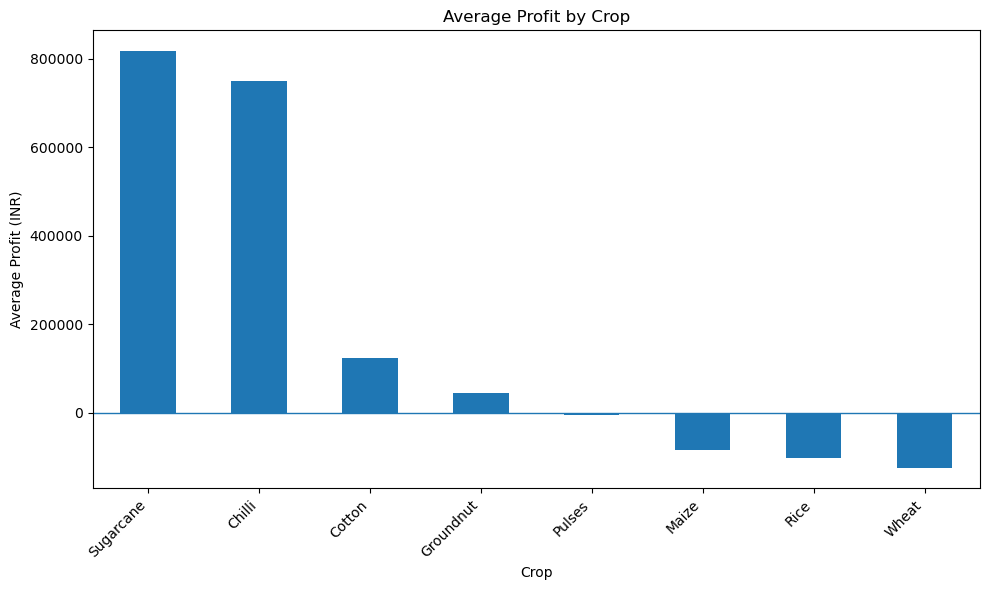

In [44]:
# Bar Graph: Average Profit by Crop

plt.figure(figsize=(10, 6))

profit_by_crop.plot(kind="bar")

plt.title("Average Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45, ha="right")
plt.axhline(0, linewidth=1)

plt.tight_layout()
plt.show() 

Main Findings

Sugarcane

Highest average profit → ₹817,187.99
Highest average yield → 46.93 t/ha

Chilli

Second-highest profit → ₹750,878.34
Yield only 1.54 t/ha, but profit very high → yield ≠ profitability

Wheat

Lowest average profit → -₹123,398.34

Maize & Rice

Both have negative average profit.

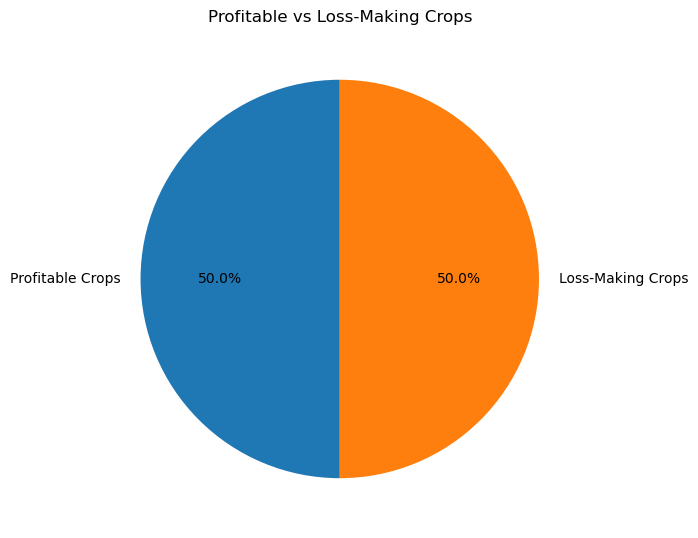

In [45]:
# Circle / Pie Chart: Profitable vs Loss-Making Crops

profitable_crops = (profit_by_crop > 0).sum()
loss_making_crops = (profit_by_crop < 0).sum()

profit_status = pd.Series({
    "Profitable Crops": profitable_crops,
    "Loss-Making Crops": loss_making_crops
})

plt.figure(figsize=(7, 7))

plt.pie(
    profit_status,
    labels=profit_status.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Profitable vs Loss-Making Crops")
plt.tight_layout()
plt.show() 

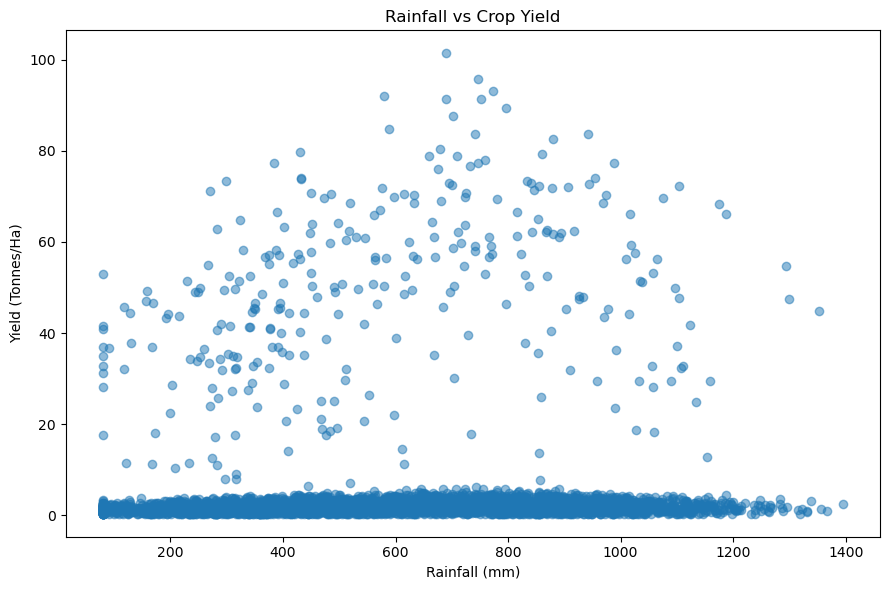

In [46]:
# Rainfall vs Crop Yield

plt.figure(figsize=(9, 6))

plt.scatter(
    df["Rainfall_mm"],
    df["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title("Rainfall vs Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show() 

In [47]:
# Calculate correlation between Rainfall and Yield

rainfall_yield_corr = df[
    ["Rainfall_mm", "Yield_Tonnes_Ha"]
].corr() 
rainfall_yield_corr

,Rainfall_mm,Yield_Tonnes_Ha
Rainfall_mm,1.000000,0.026933
Yield_Tonnes_Ha,0.026933,1.000000


RRainfall vs Yield
Correlation = 0.0269 → very weak positive relationship.
Rainfall alone → negligible linear relationship with yield.
Other factors also matter → crop, soil, irrigation, temperature, fertilizer, farming practices.
Important: correlation ≠ causation.

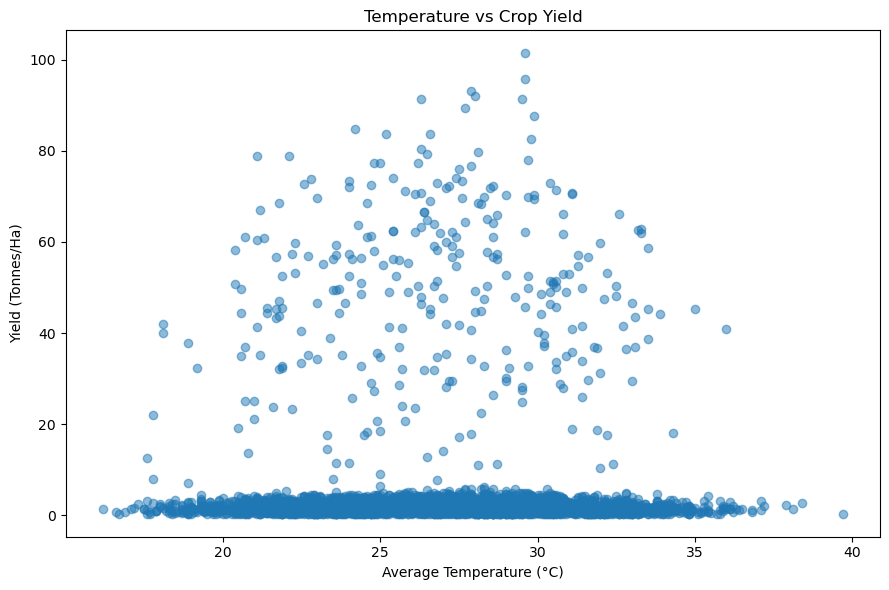

In [48]:
# Temperature vs Crop Yield

plt.figure(figsize=(9, 6))

plt.scatter(
    df["Avg_Temperature_C"],
    df["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title("Temperature vs Crop Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show() 

In [49]:
# Calculate correlation between Temperature and Yield

temperature_yield_corr = df[
    ["Avg_Temperature_C", "Yield_Tonnes_Ha"]
].corr()

temperature_yield_corr 

,Avg_Temperature_C,Yield_Tonnes_Ha
Avg_Temperature_C,1.000000,0.009237
Yield_Tonnes_Ha,0.009237,1.000000


Interpretation
Correlation = 0.0092
This indicates a negligible/very weak positive linear relationship between average temperature and crop yield in this dataset.
The scatter plot also shows that the observations are widely dispersed rather than following a clear upward or downward pattern.

So, just like rainfall, temperature alone does not show a meaningful linear relationship with yield in this dataset.

In [50]:
# Irrigation Method vs Average Yield

irrigation_summary = df.groupby("Irrigation_Method").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round(2)

irrigation_summary.sort_values(
    "Average_Yield",
    ascending=False
) 

,Average_Yield,Average_Profit,Average_Water_Used
Irrigation_Method,,,
Drip,6.68,219626.00,5918.75
Sprinkler,5.16,91121.08,6208.26
Flood,4.86,73354.02,8026.47
Rainfed,4.60,79050.37,3549.55


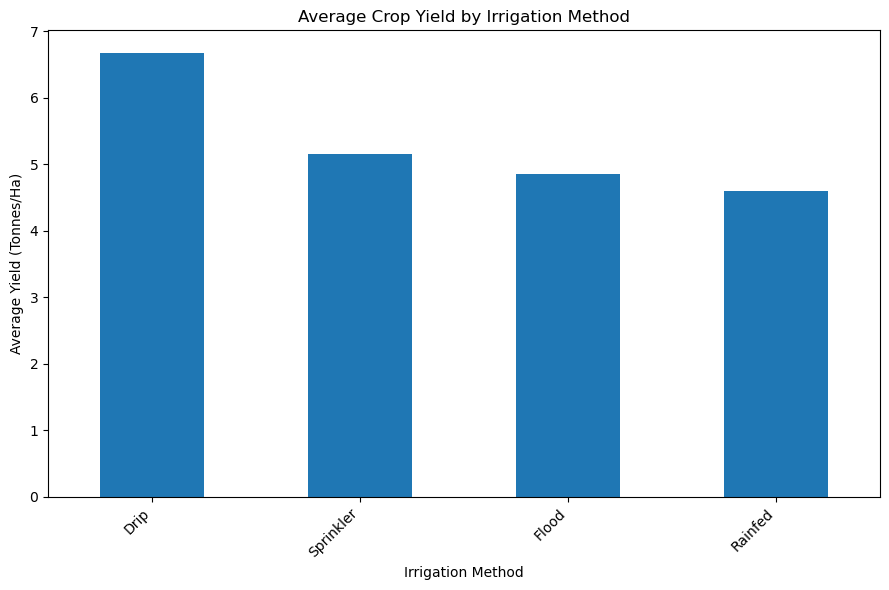

In [51]:
# Average Yield by Irrigation Method

plt.figure(figsize=(9, 6))

irrigation_summary["Average_Yield"].sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Average Crop Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show() 


Irrigation — Quick Findings

💧 Drip

Highest yield → 6.68 t/ha
Highest profit → ₹219,626
Best overall

🚿 Flood

Yield → 4.86 t/ha
Highest water usage → 8,026.47 m³
More water, lower yield than Drip

🌧️ Rainfed

Lowest yield → 4.60 t/ha
Lowest water usage → 3,549.55 m³
Less supplied irrigation → less water usage

In [52]:
# Water efficiency by irrigation method

water_efficiency = df.groupby("Irrigation_Method").agg(
    Average_Water_Efficiency=(
        "Water_Efficiency_t_per_1000m3", "mean"
    ),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round(2)

water_efficiency.sort_values(
    "Average_Water_Efficiency",
    ascending=False
) 

,Average_Water_Efficiency,Average_Yield,Average_Water_Used
Irrigation_Method,,,
Rainfed,7.56,4.60,3549.55
Drip,6.27,6.68,5918.75
Sprinkler,4.67,5.16,6208.26
Flood,3.44,4.86,8026.47


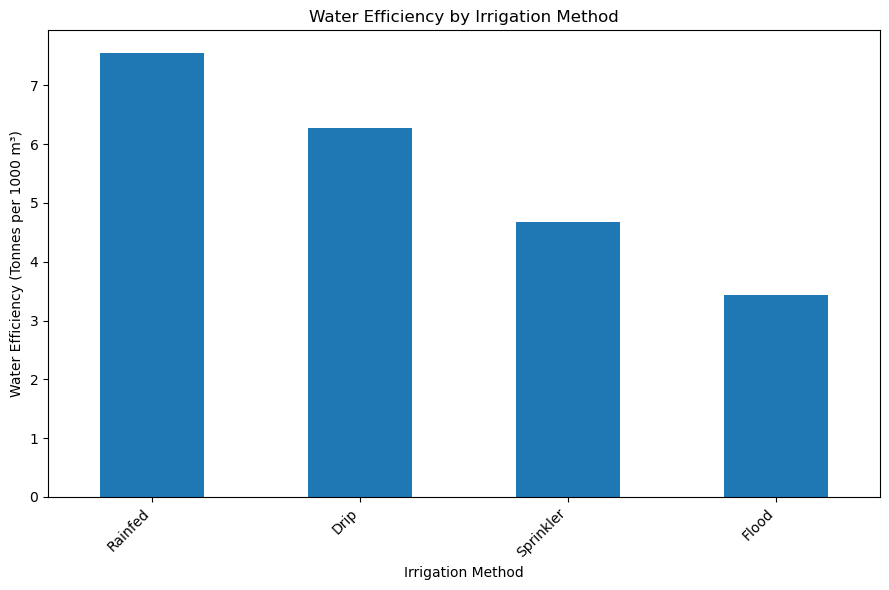

In [53]:
# Average Water Efficiency by Irrigation Method

plt.figure(figsize=(9, 6))

water_efficiency["Average_Water_Efficiency"].sort_values(
    ascending=False
).plot(kind="bar")

plt.title("Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency (Tonnes per 1000 m³)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show() 

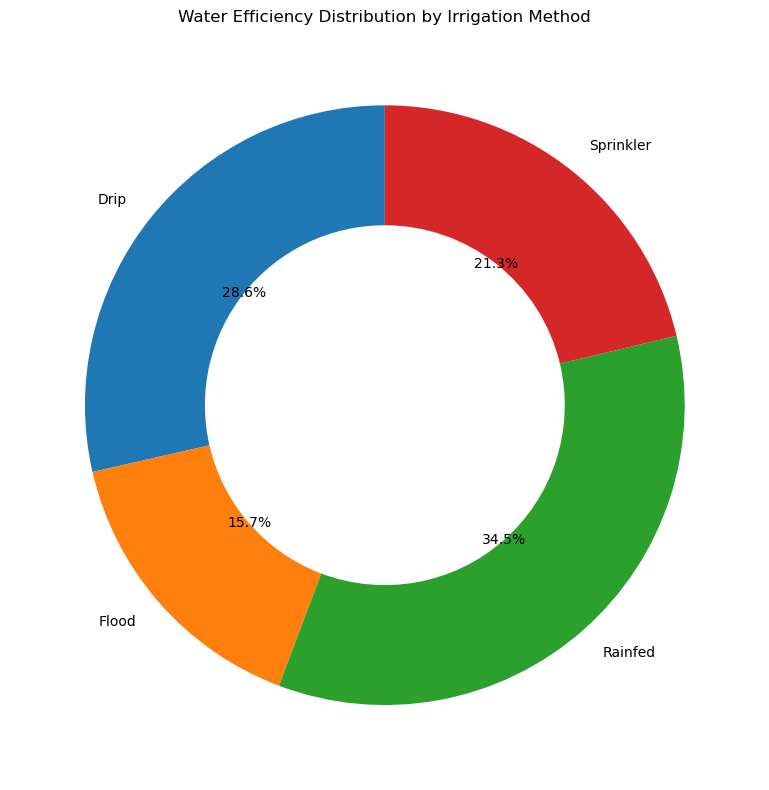

In [54]:
plt.figure(figsize=(8, 8))

plt.pie(
    water_efficiency["Average_Water_Efficiency"],
    labels=water_efficiency.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.4)
)

plt.title("Water Efficiency Distribution by Irrigation Method")

plt.tight_layout()
plt.show() 

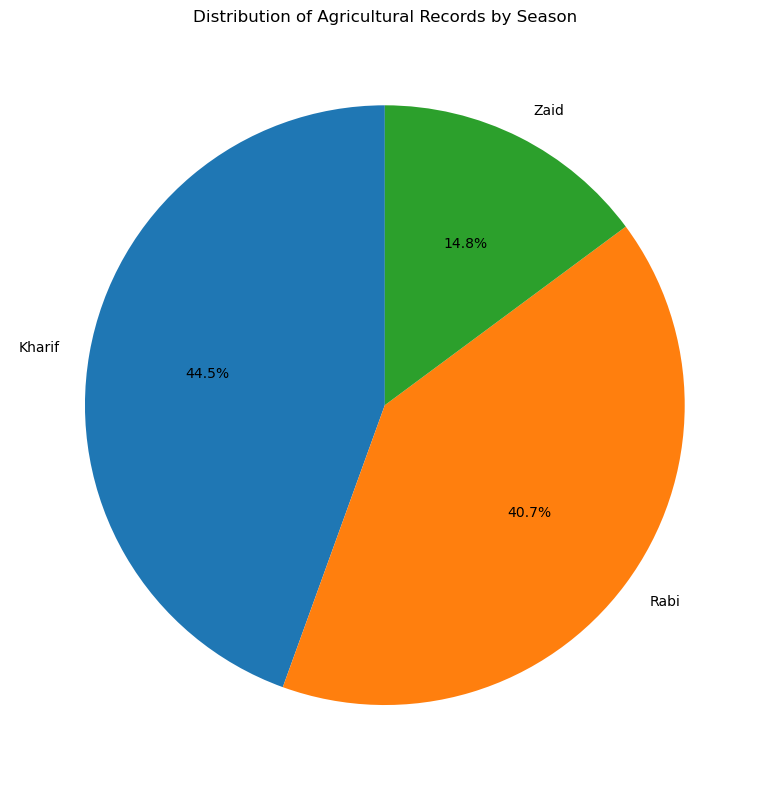

In [55]:
season_counts = df["Season"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    season_counts,
    labels=season_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Agricultural Records by Season")

plt.tight_layout()
plt.show() 

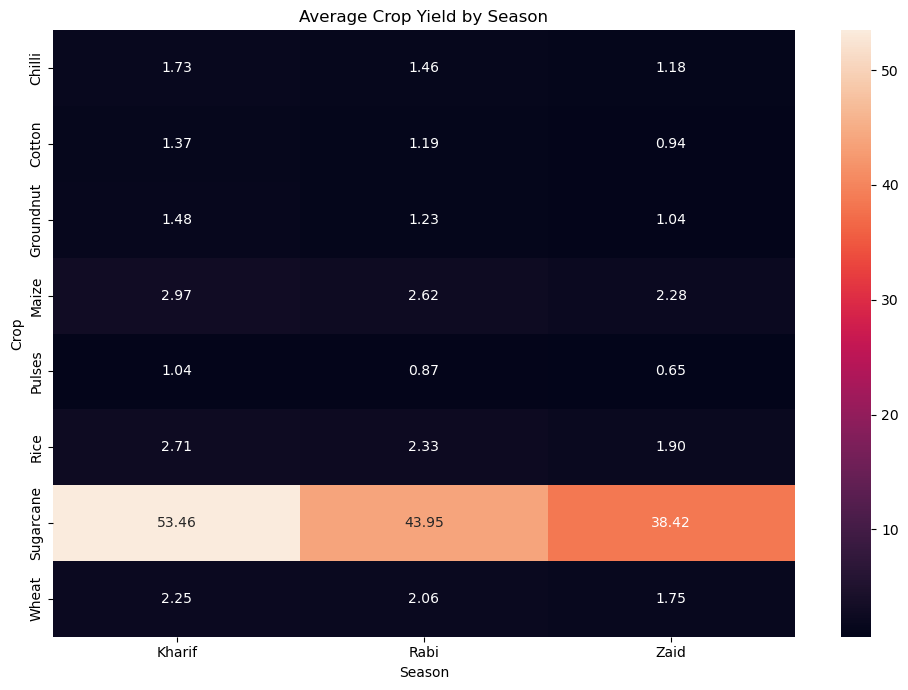

In [56]:
# Season-wise Crop Yield Heatmap

season_crop_yield = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    season_crop_yield,
    annot=True,
    fmt=".2f"
)

plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Crop")

plt.tight_layout()
plt.show() 

In [57]:
season_crop_yield.round(2) 

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.94
Groundnut,1.48,1.23,1.04
Maize,2.97,2.62,2.28
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.95,38.42
Wheat,2.25,2.06,1.75


highest combination:
Sugarcane + Kharif = 53.46 tonnes/ha

🥈 Second:
Sugarcane + Rabi = 43.95 tonnes/ha

🥉 Third:
Sugarcane + Zaid = 38.42 tonnes/ha

For almost every crop, the pattern is:

Kharif > Rabi > Zaid

For example:

Maize: 2.97 → 2.62 → 2.28
Rice: 2.71 → 2.33 → 1.90
Wheat: 2.25 → 2.06 → 1.75
Pulses: 1.04 → 0.87 → 0.65

In [58]:
# Average Profit by Season

season_profit = df.groupby("Season").agg(
    Average_Profit=("Profit_INR", "mean"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Cost=("Total_Cost_INR", "mean")
).round(2)

season_profit 

,Average_Profit,Average_Revenue,Average_Cost
Season,,,
Kharif,178914.65,710719.06,531804.41
Rabi,87689.47,601526.05,513836.58
Zaid,-24804.82,519171.90,543976.73


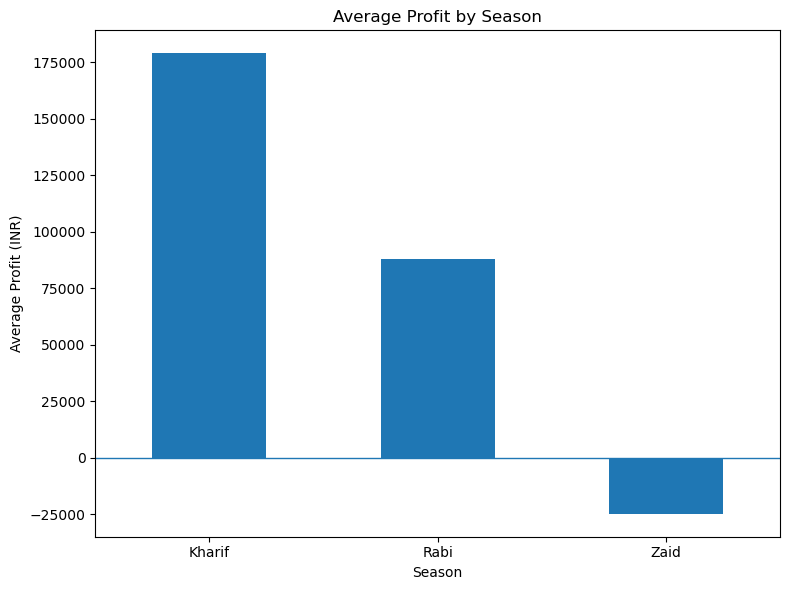

In [59]:
# Average Profit by Season

plt.figure(figsize=(8, 6))

season_profit["Average_Profit"].plot(kind="bar")

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)

plt.axhline(0, linewidth=1)

plt.tight_layout()
plt.show() 

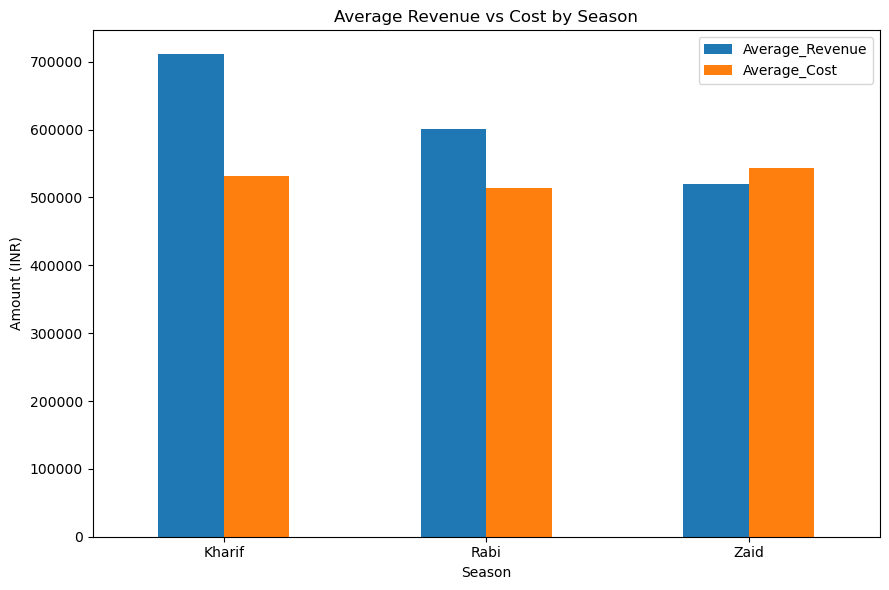

In [60]:
# Revenue vs Cost by Season

season_profit[["Average_Revenue", "Average_Cost"]].plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Average Revenue vs Cost by Season")
plt.xlabel("Season")
plt.ylabel("Amount (INR)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show() 

Final result
Kharif: ₹178,914.83 → highest average profit
Rabi: ₹87,689.47
Zaid: -₹24,804.82 → average loss

Project finding:

Kharif is the most profitable season, while Zaid records a negative average profit. 
This indicates significant seasonal variation in agricultural economic performance.

Revenue vs Cost — Quick Findings
🌾 Kharif → Highest revenue + revenue > cost → strong profitability
🌱 Rabi → Revenue > cost → profitable
☀️ Zaid → Cost > revenue → negative profit
Overall → Kharif strongest, Zaid weakest.

Correlation between Fertilizer Usage and Yield: -0.0003


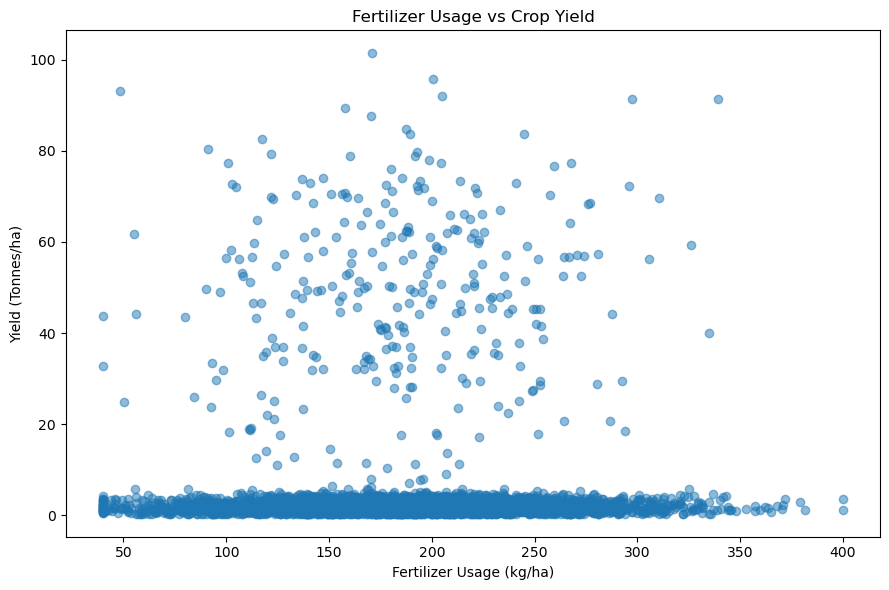

In [61]:
# Step 3.11.1 - Fertilizer Usage vs Yield

fertilizer_yield_corr = df["Fertilizer_kg_ha"].corr(
    df["Yield_Tonnes_Ha"]
)

print("Correlation between Fertilizer Usage and Yield:",
      round(fertilizer_yield_corr, 4))

plt.figure(figsize=(9, 6))

plt.scatter(
    df["Fertilizer_kg_ha"],
    df["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title("Fertilizer Usage vs Crop Yield")
plt.xlabel("Fertilizer Usage (kg/ha)")
plt.ylabel("Yield (Tonnes/ha)")

plt.tight_layout()
plt.show() 

Fertilizer vs Yield — Quick Findings
Correlation = -0.0003 → almost negligible linear relationship.
Yield values are widely scattered across fertilizer usage.
Fertilizer alone is not a strong predictor of yield in this dataset.

Correlation between Fertilizer Usage and Profit: -0.0735


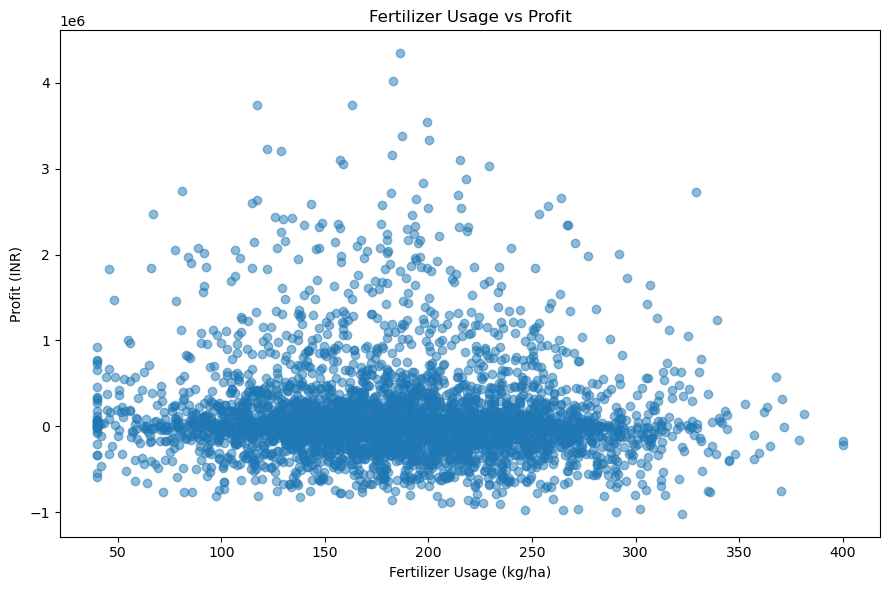

In [62]:
# Step 3.11.2 - Fertilizer Usage vs Profit

fertilizer_profit_corr = df["Fertilizer_kg_ha"].corr(
    df["Profit_INR"]
)

print("Correlation between Fertilizer Usage and Profit:",
      round(fertilizer_profit_corr, 4))

plt.figure(figsize=(9, 6))

plt.scatter(
    df["Fertilizer_kg_ha"],
    df["Profit_INR"],
    alpha=0.5
)

plt.title("Fertilizer Usage vs Profit")
plt.xlabel("Fertilizer Usage (kg/ha)")
plt.ylabel("Profit (INR)")

plt.tight_layout()
plt.show() 

Fertilizer vs Profit — Quick Findings
Correlation = -0.0735 → very weak negative relationship.
Fertilizer usage alone → not a strong predictor of profit.
Profit depends on crop, market price, production, cost, season & farming practices.

Correlation between Water Usage and Yield: 0.3874


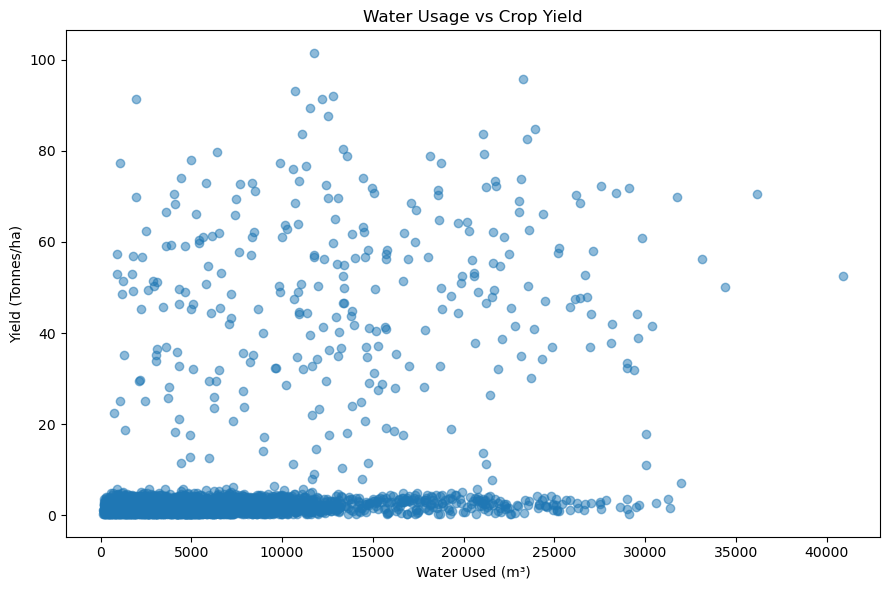

In [63]:
# Step 3.11.3 - Water Usage vs Yield

water_yield_corr = df["Water_Used_m3"].corr(
    df["Yield_Tonnes_Ha"]
)

print("Correlation between Water Usage and Yield:",
      round(water_yield_corr, 4))

plt.figure(figsize=(9, 6))

plt.scatter(
    df["Water_Used_m3"],
    df["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title("Water Usage vs Crop Yield")
plt.xlabel("Water Used (m³)")
plt.ylabel("Yield (Tonnes/ha)")

plt.tight_layout()
plt.show()

Correlation between Disease/Pest Risk and Yield: 0.0127


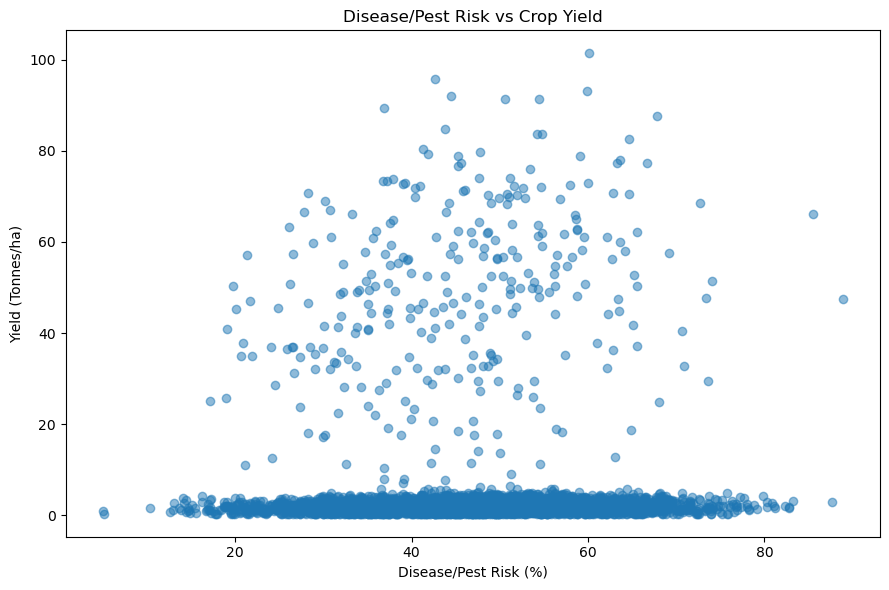

In [64]:
# Step 3.11.4 - Disease/Pest Risk vs Yield

risk_yield_corr = df["Disease_Pest_Risk_pct"].corr(
    df["Yield_Tonnes_Ha"]
)

print("Correlation between Disease/Pest Risk and Yield:",
      round(risk_yield_corr, 4))

plt.figure(figsize=(9, 6))

plt.scatter(
    df["Disease_Pest_Risk_pct"],
    df["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title("Disease/Pest Risk vs Crop Yield")
plt.xlabel("Disease/Pest Risk (%)")
plt.ylabel("Yield (Tonnes/ha)")

plt.tight_layout()
plt.show()

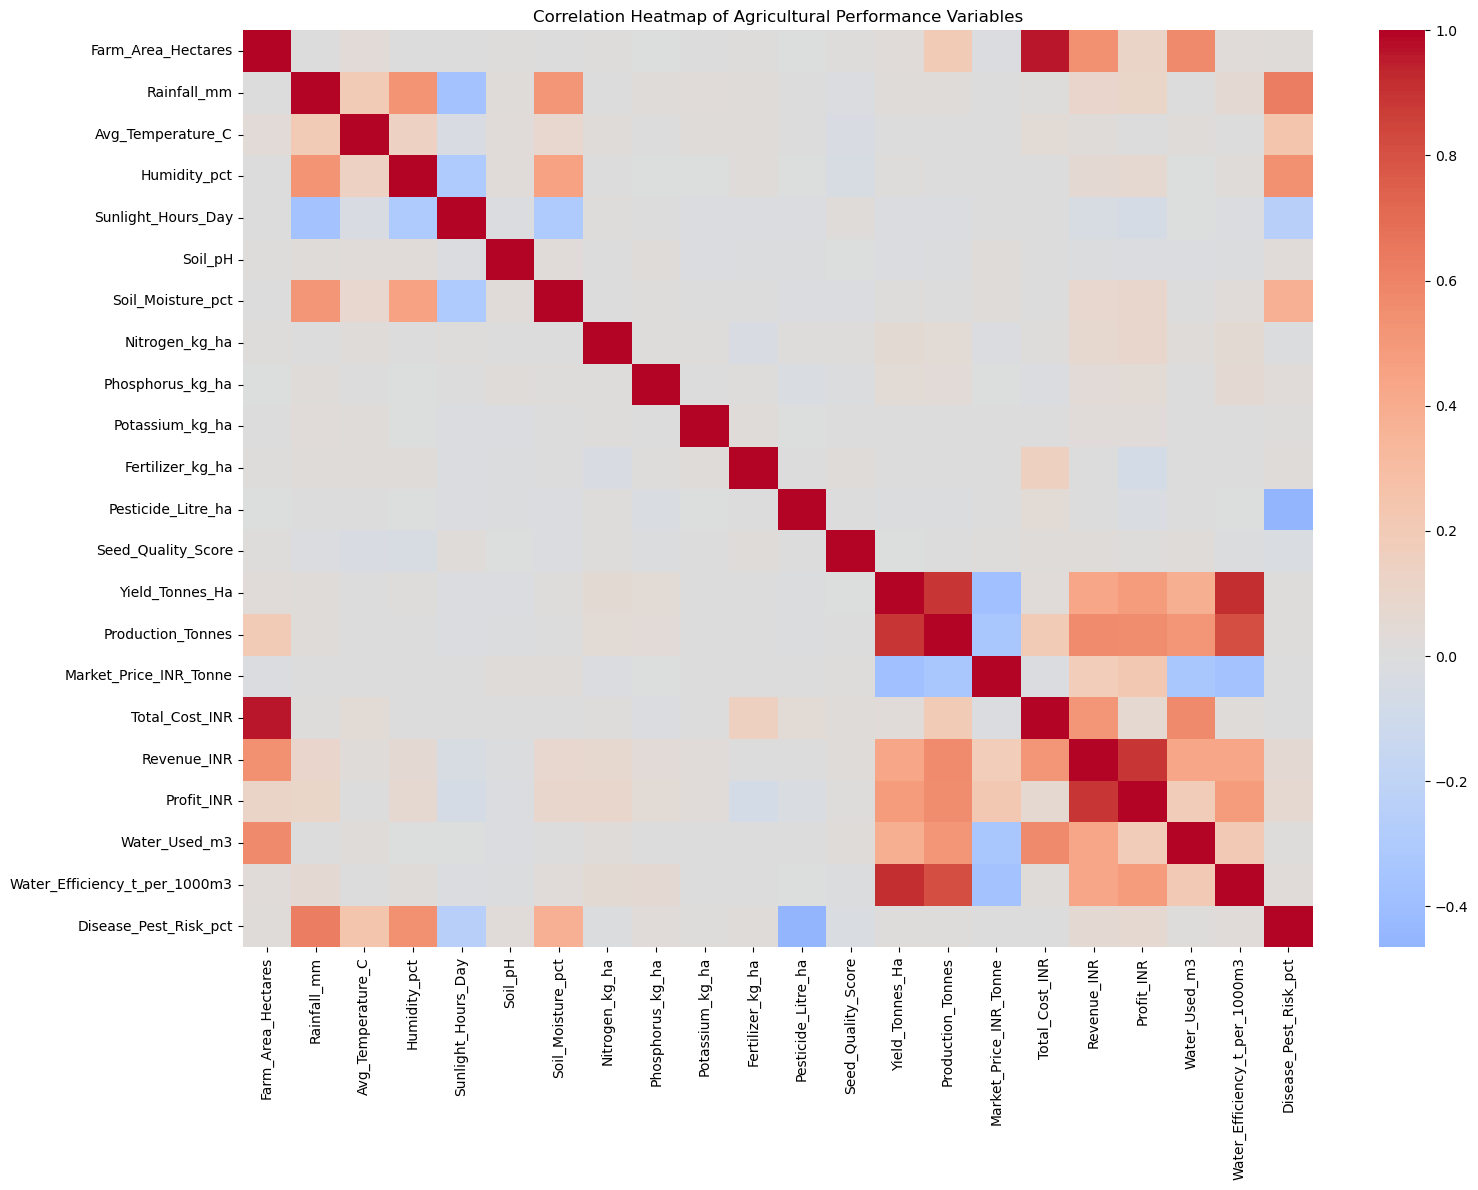

In [65]:
# Step 3.12 - Correlation Heatmap

numeric_columns = [
    "Farm_Area_Hectares",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Market_Price_INR_Tonne",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Agricultural Performance Variables")
plt.tight_layout()
plt.show()

### Finding – Correlation Analysis

The correlation heatmap provides an overall view of relationships among environmental, resource, production 
and economic variables.

The analysis helps identify variables that show stronger or 
    weaker linear relationships with agricultural performance.
    However, correlation indicates association rather than causation,
and agricultural outcomes are influenced by multiple interacting factors.

In [66]:
# Step 3.13 - Resource Usage by Season

resource_season = df.groupby("Season").agg(
    Average_Fertilizer=("Fertilizer_kg_ha", "mean"),
    Average_Pesticide=("Pesticide_Litre_ha", "mean"),
    Average_Water=("Water_Used_m3", "mean"),
    Average_Rainfall=("Rainfall_mm", "mean"),
    Average_Soil_Moisture=("Soil_Moisture_pct", "mean")
).round(2)

display(resource_season) 

,Average_Fertilizer,Average_Pesticide,Average_Water,Average_Rainfall,Average_Soil_Moisture
Season,,,,,
Kharif,187.08,5.08,6102.20,852.11,31.20
Rabi,185.41,5.02,5846.99,435.94,24.05
Zaid,184.64,5.17,6419.89,299.12,19.17


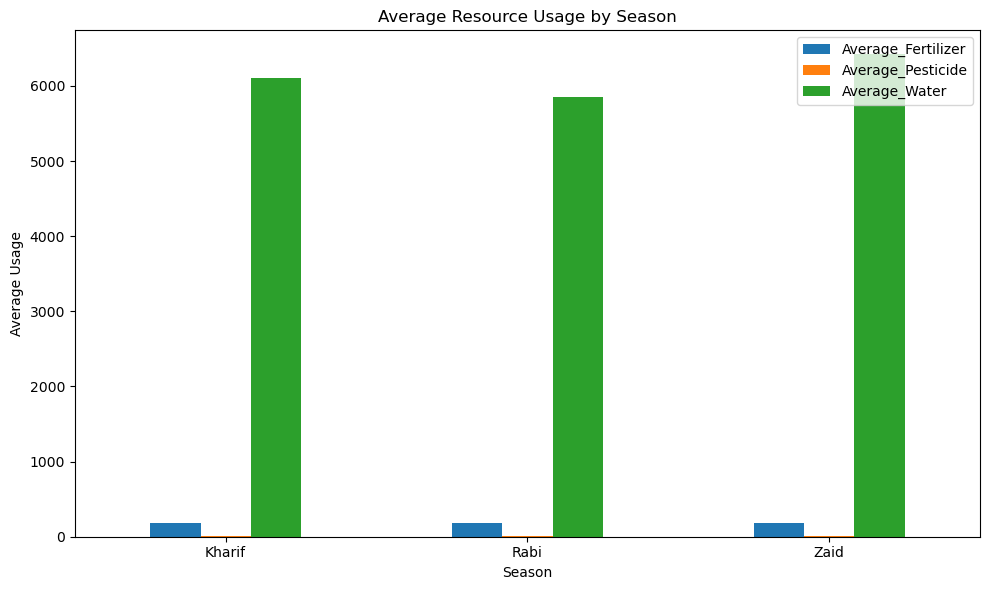

In [67]:
resource_season[
    ["Average_Fertilizer", "Average_Pesticide", "Average_Water"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Resource Usage by Season")
plt.xlabel("Season")
plt.ylabel("Average Usage")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Resource Usage Across Seasons 
Kharif, Rabi & Zaid → resource usage differs by season.
Fertilizer, pesticide & water → different usage patterns.
Overall → useful for season-wise resource planning & input allocation.

In [68]:
# Step 3.14 - Seasonal Performance Comparison

season_performance = df.groupby("Season").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
)

display(season_performance.round(2))

,Average_Yield,Average_Revenue,Average_Profit,Average_Water_Efficiency
Season,,,,
Kharif,5.63,710719.06,178914.65,5.89
Rabi,5.09,601526.05,87689.47,5.19
Zaid,4.63,519171.90,-24804.82,4.41


In [69]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

score_data = season_performance.copy()

score_data[
    ["Average_Yield",
     "Average_Revenue",
     "Average_Profit",
     "Average_Water_Efficiency"]
] = scaler.fit_transform(
    score_data[
        ["Average_Yield",
         "Average_Revenue",
         "Average_Profit",
         "Average_Water_Efficiency"]
    ]
)

score_data["Overall_Performance_Score"] = (
    score_data[
        ["Average_Yield",
         "Average_Revenue",
         "Average_Profit",
         "Average_Water_Efficiency"]
    ].mean(axis=1)
)

score_data = score_data.sort_values(
    "Overall_Performance_Score",
    ascending=False
)

display(score_data.round(3))

,Average_Yield,Average_Revenue,Average_Profit,Average_Water_Efficiency,Overall_Performance_Score
Season,,,,,
Kharif,1.000,1.00,1.000,1.000,1.000
Rabi,0.462,0.43,0.552,0.523,0.492
Zaid,0.000,0.00,0.000,0.000,0.000


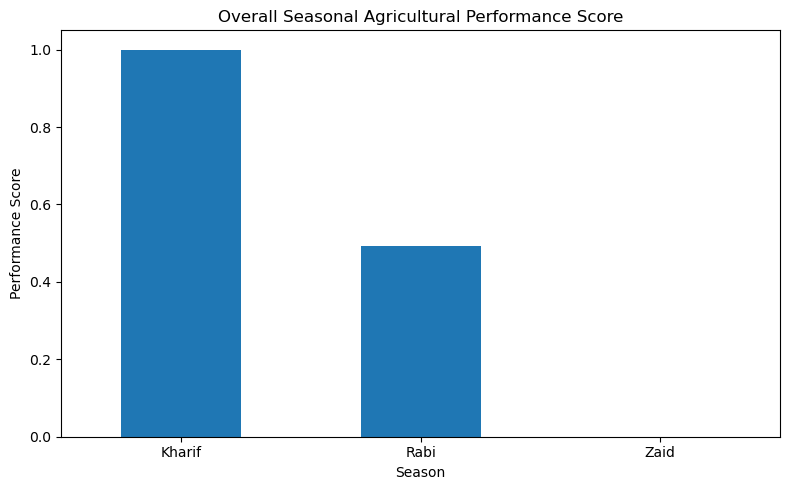

In [70]:
plt.figure(figsize=(8, 5))

score_data["Overall_Performance_Score"].plot(
    kind="bar"
)

plt.title("Overall Seasonal Agricultural Performance Score")
plt.xlabel("Season")
plt.ylabel("Performance Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Finding – Overall Seasonal Performance
Performance Score → combines Yield + Revenue + Profit + Water Efficiency.
Overall comparison → evaluates seasons using multiple indicators.
Key point → gives a broader view of seasonal performance, not just one metric.

In [71]:
# Step 3.15 - Yield Outlier Analysis

Q1 = df["Yield_Tonnes_Ha"].quantile(0.25)
Q3 = df["Yield_Tonnes_Ha"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

yield_outliers = df[
    (df["Yield_Tonnes_Ha"] < lower_bound) |
    (df["Yield_Tonnes_Ha"] > upper_bound)
]

print("Number of Yield Outliers:", len(yield_outliers))
print("Lower Bound:", round(lower_bound, 2))
print("Upper Bound:", round(upper_bound, 2)) 

Number of Yield Outliers: 304
Lower Bound: -1.63
Upper Bound: 5.52


### Performance Score Methodology

- Metrics used → Yield, Revenue, Profit & Water Efficiency
- Normalization → Min-Max Scaling
- Weight → Equal weight for all 4 metrics
- Purpose → Compare overall seasonal performance
- Note → Project-specific score for this dataset only

#Key Findings and Insights


Seasonal Performance: Kharif recorded the highest average yield and average profit, while Zaid showed the lowest average yield and negative average profit.
Crop Performance: Sugarcane recorded the highest average yield and average profit. Chilli also showed strong profitability despite its relatively lower yield.
State Performance: Punjab recorded the highest average yield among the analyzed states, while Andhra Pradesh recorded the lowest average yield.
Profitability: Yield alone does not determine profitability. Market price, production cost, production volume and crop characteristics also influence economic performance.
Environmental Relationships: Rainfall and temperature showed negligible linear relationships with yield in this dataset, indicating that these variables alone are not strong linear predictors of yield.
Irrigation: Drip irrigation was associated with the highest average yield and average profit among the analyzed irrigation methods.
Water Efficiency: Rainfed farming showed the highest average water-efficiency metric, while flood irrigation showed the lowest, highlighting differences between water efficiency and overall productivity.
Season-Crop Pattern: Kharif generally showed higher average yield than Rabi and Zaid across the analyzed crops.
Economic Performance: Kharif generated higher average revenue than cost, whereas Zaid had average cost higher than average revenue, resulting in negative average profit.
Resource Planning: Differences in fertilizer, pesticide and water usage across seasons highlight the importance of season-specific agricultural resource planning.
Outliers: Extreme yield values were retained because they may represent genuine differences between crop categories rather than data errors.
Multi-dimensional Performance: Agricultural performance should be evaluated using multiple indicators such as yield, profitability, resource efficiency and environmental conditions rather than relying on a single metric.

#Recommendations

Prioritize Seasonal Planning: Since Kharif showed stronger overall performance, crop and resource strategies can be planned according to the conditions and practices that perform well during this season.
Improve Zaid Profitability: Since Zaid showed negative average profit, crop selection, input costs, irrigation requirements and expected market prices should be evaluated carefully before cultivation.
Promote Efficient Irrigation: Drip irrigation was associated with higher average yield and profitability and can be considered where economically and geographically suitable.
Optimize Water Usage: Irrigation planning should consider both crop productivity and water consumption to improve resource efficiency.
Use Crop-Specific Strategies: Since crop performance varies substantially, fertilizer, irrigation and other resource requirements should be adapted to individual crop needs.
Consider Economic Factors: Crop decisions should consider expected market price, production cost, production volume and profitability rather than focusing only on yield.
Monitor Environmental Conditions: Rainfall, temperature, soil conditions and disease/pest risk should be monitored as part of seasonal agricultural planning.
Use Data-Driven Decision Making: Historical agricultural data can support better crop selection, seasonal planning, resource allocation and profitability assessment.
Investigate Extreme Observations: Unusual yield or profit observations should be reviewed separately to understand the conditions associated with exceptionally high or low performance.

# Conclusion

The Seasonal Agriculture Performance Analysis provided insights into agricultural performance across different seasons, crops, regions, environmental conditions, resource usage and economic outcomes.

The analysis identified clear seasonal differences, with Kharif showing stronger overall yield and profitability, while Zaid showed weaker performance and negative average profitability. Crop-level analysis highlighted substantial differences in productivity and profitability, with Sugarcane showing the highest average yield and profit. State-level analysis also revealed regional variations in agricultural performance.

The analysis further showed differences in irrigation, water efficiency and resource usage. Correlation analysis indicated that some individual environmental and resource variables had weak linear relationships with yield, suggesting that agricultural performance depends on multiple interacting factors rather than a single variable.

Overall, the project demonstrates how data cleaning, analysis and visualization can transform raw agricultural data into meaningful insights. These insights can support seasonal planning, resource allocation, crop selection and profitability assessment.